<a href="https://colab.research.google.com/github/Dr-Isam-ALJAWARNEH/fds-project-space-time-clustering-for-aq/blob/main/Sampling_Chicago_Space_Time_Clustering_of_Mobility_Patterns_and_Air_Quality_Hotspots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Project Title: Space-Time Clustering of Mobility Patterns and Air Quality Hotspots for Chicago**

4. Sampling Design

In [ ]:
# 1. Random Sampling Function
def random_sample(df, frac=0.6, seed=42):
    """
    Randomly sample a fraction of the dataframe.
    """
    return df.sample(frac=frac, random_state=seed)


In [ ]:
# 2. Stratified Sampling Function (by 'community_area')
def stratified_sample(df, stratify_col='community', frac=0.6, seed=42):
    """
    Stratified sample: Sample a fraction from each community area.
    """
    stratified_df = (
        df.groupby(stratify_col, group_keys=False)
          .apply(lambda x: x.sample(frac=frac, random_state=seed))
    )
    return stratified_df


In [ ]:
# 3. Statistics Comparison Function
def compare_statistics(original_df, sample_df, variables):
    """
    Compare mean and standard deviation between original data and sample data.
    """
    return pd.DataFrame({
        'Original_Mean': original_df[variables].mean(),
        'Sample_Mean': sample_df[variables].mean(),
        'Original_STD': original_df[variables].std(),
        'Sample_STD': sample_df[variables].std()
    })

In [ ]:
# Perform Random Sampling
random_sampled = random_sample(joined_sorted, frac=0.6)

# Perform Stratified Sampling
stratified_sampled = stratified_sample(joined_sorted, stratify_col='community', frac=0.6)

# Select important variables to compare
variables_to_check = ['PM25', 'total_trip_count']

# Compare Statistics
random_stats = compare_statistics(joined_sorted, random_sampled, variables_to_check)
stratified_stats = compare_statistics(joined_sorted, stratified_sampled, variables_to_check)

# Display
print("Random Sampling Statistics Comparison:")
display(random_stats)

print("Stratified Sampling Statistics Comparison:")
display(stratified_stats)

Random Sampling Statistics Comparison:


<ipython-input-36-72751188534e>:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=frac, random_state=seed))


,Original_Mean,Sample_Mean,Original_STD,Sample_STD
PM25,9.021397,8.984195,6.769956,6.722259
total_trip_count,15.962474,16.012740,24.079940,24.111450


Stratified Sampling Statistics Comparison:


,Original_Mean,Sample_Mean,Original_STD,Sample_STD
PM25,9.021397,8.993814,6.769956,6.757659
total_trip_count,15.962474,16.232120,24.079940,24.410539


Both sampling methods are statistically good, BUT stratified sampling is better because:

1- space-time clustering depends on spatial fairness (communities must be equally represented).

2- Random sampling might under-sample small or rare community areas, making later clustering biased.

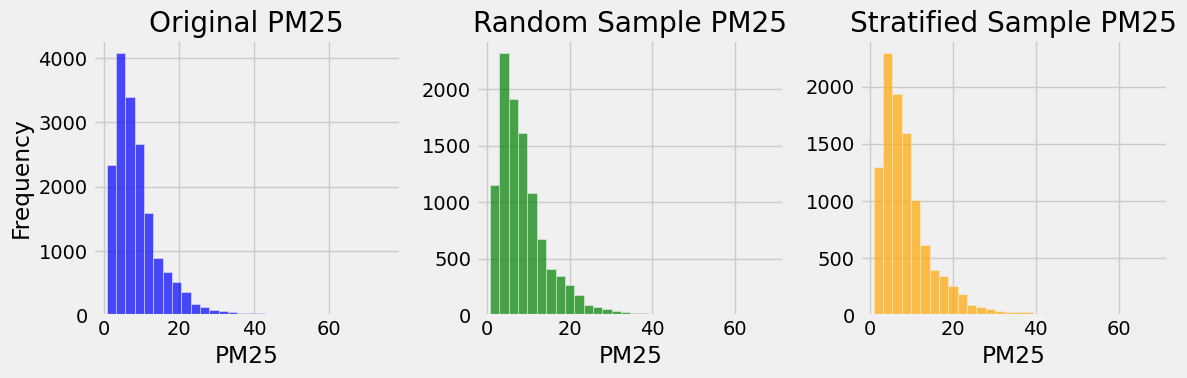

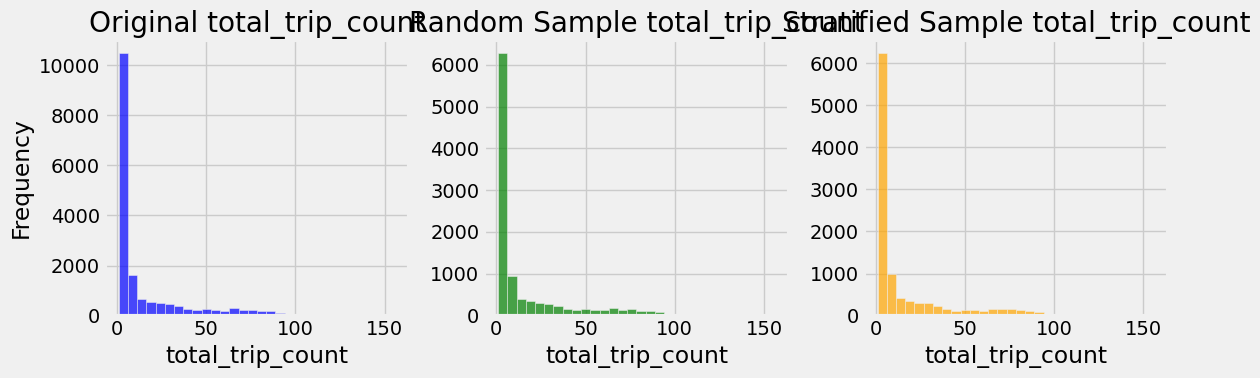

In [ ]:
variables_to_plot = ['PM25', 'total_trip_count']

for var in variables_to_plot:
    plt.figure(figsize=(12, 4))

    # Original
    plt.subplot(1, 3, 1)
    plt.hist(joined_sorted[var], bins=30, alpha=0.7, color='blue')
    plt.title(f'Original {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')

    # Random Sample
    plt.subplot(1, 3, 2)
    plt.hist(random_sampled[var], bins=30, alpha=0.7, color='green')
    plt.title(f'Random Sample {var}')
    plt.xlabel(var)

    # Stratified Sample
    plt.subplot(1, 3, 3)
    plt.hist(stratified_sampled[var], bins=30, alpha=0.7, color='orange')
    plt.title(f'Stratified Sample {var}')
    plt.xlabel(var)

    plt.tight_layout()
    plt.show()


From the histograms, we observe that:

Both PM2.5 and total_trip_count are heavily right-skewed across the original, random sample, and stratified sample datasets. This indicates a concentration of low pollution and trip activity, with fewer instances of high values — a common pattern in urban mobility and air quality data.

Random Sampling approximates the original distribution well, but may slightly underrepresent certain community areas or rare events.

Stratified Sampling not only preserves the distribution shape, but ensures better community-level representation, which is crucial for space-time clustering, especially when analyzing pollution hotspots and human mobility across all city regions.